## Compare model performance with baseline ICEBERG predictions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)

# Set visualization style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 14})

print("[+] Environment successfully set up.")

[+] Environment successfully set up.


In [2]:
# UPDATE THESE PATHS
YOUR_MODEL_CSV = "/data/nas-gpu/wang/tmach007/ms-pred/fiar_pipeline/results/phase3_probe/eval/test_colbert_probe_predictions_nist.csv" 
ICEBERG_CSV = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/msg_iceberg_predictions/iceberg_classification_results.csv"

# Load the data
df_ours = pd.read_csv(YOUR_MODEL_CSV)
df_iceberg = pd.read_csv(ICEBERG_CSV)

# Drop any NaNs just in case
df_ours = df_ours.dropna(subset=['true_label', 'predicted_label', 'prob_similarity'])
df_iceberg = df_iceberg.dropna(subset=['true_label', 'predicted_label', 'cosine_similarity'])

print(f"[+] Loaded Siamese Model: {len(df_ours)} pairs")
print(f"[+] Loaded ICEBERG-2 Model: {len(df_iceberg)} pairs")

[+] Loaded Siamese Model: 1650 pairs
[+] Loaded ICEBERG-2 Model: 1650 pairs


In [3]:
def calculate_metrics(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

# Calculate for our model
metrics_ours = calculate_metrics(
    df_ours['true_label'], 
    df_ours['predicted_label'], 
    df_ours['prob_similarity']
)

# Calculate for ICEBERG-2
metrics_iceberg = calculate_metrics(
    df_iceberg['true_label'], 
    df_iceberg['predicted_label'], 
    df_iceberg['cosine_similarity']
)

# Create a comparison DataFrame
comparison_df = pd.DataFrame([metrics_ours, metrics_iceberg], index=["Our Siamese Model", "ICEBERG-2 Baseline"]).T
display(comparison_df.round(4))

,Our Siamese Model,ICEBERG-2 Baseline
Accuracy,0.7818,0.6642
Precision,0.8047,0.8320
Recall,0.7790,0.4624
F1-Score,0.7917,0.5944
ROC-AUC,0.8513,0.7612


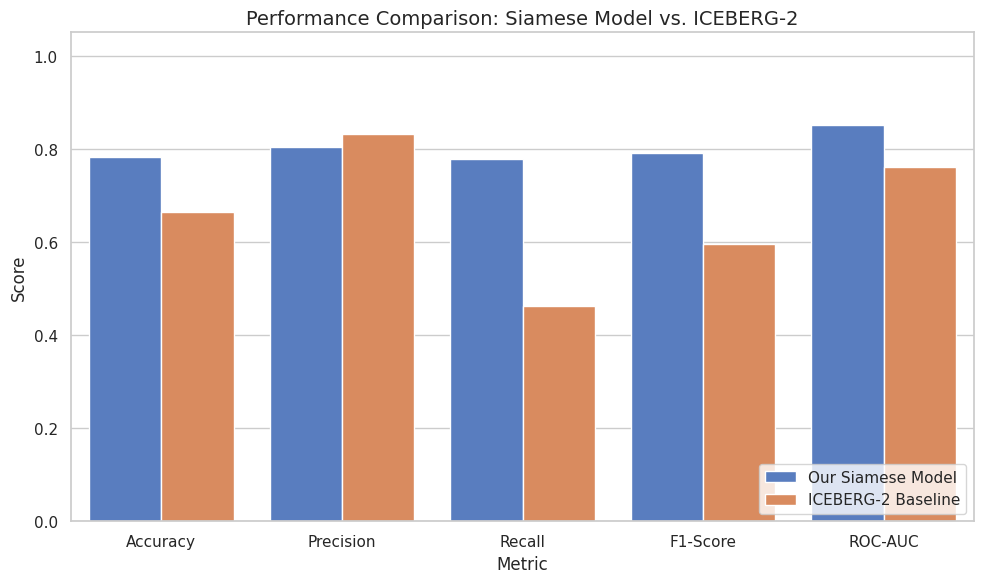

In [4]:
# Melt the dataframe for Seaborn plotting
plot_df = comparison_df.reset_index().melt(id_vars='index', var_name='Model', value_name='Score')
plot_df.rename(columns={'index': 'Metric'}, inplace=True)

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x='Metric', y='Score', hue='Model')
plt.title('Performance Comparison: Siamese Model vs. ICEBERG-2')
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

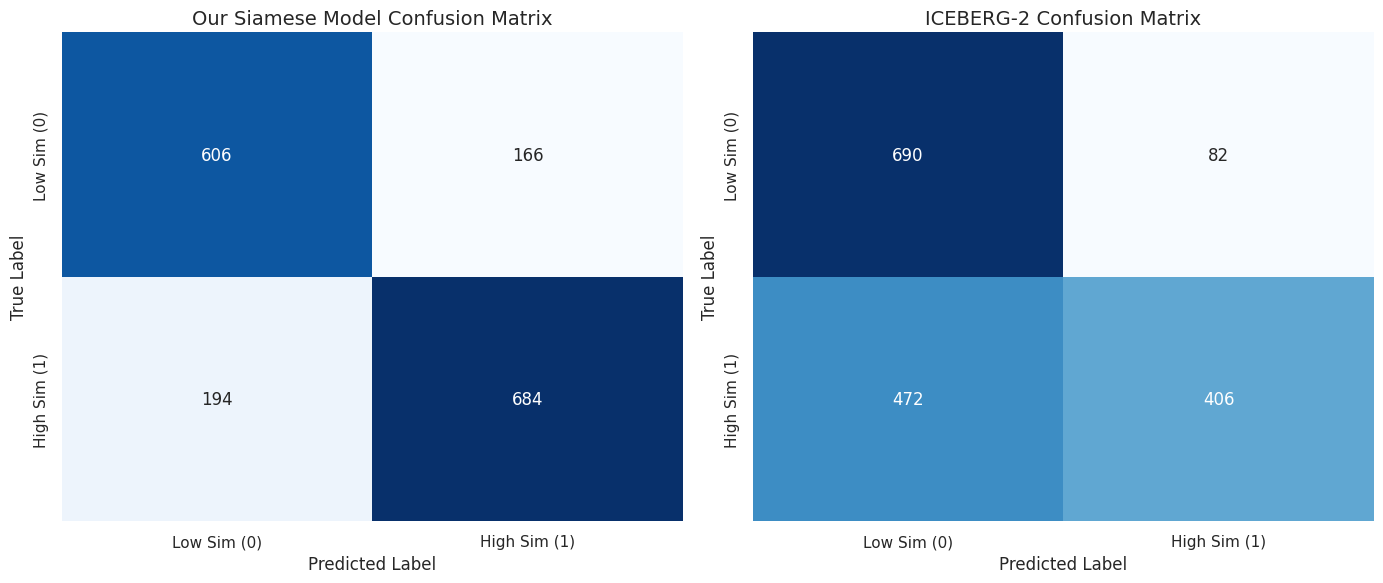

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

def plot_cm(y_true, y_pred, ax, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Low Sim (0)', 'High Sim (1)'],
                yticklabels=['Low Sim (0)', 'High Sim (1)'])
    ax.set_title(title)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plot_cm(df_ours['true_label'], df_ours['predicted_label'], axes[0], 'Our Siamese Model Confusion Matrix')
plot_cm(df_iceberg['true_label'], df_iceberg['predicted_label'], axes[1], 'ICEBERG-2 Confusion Matrix')

plt.tight_layout()
plt.show()

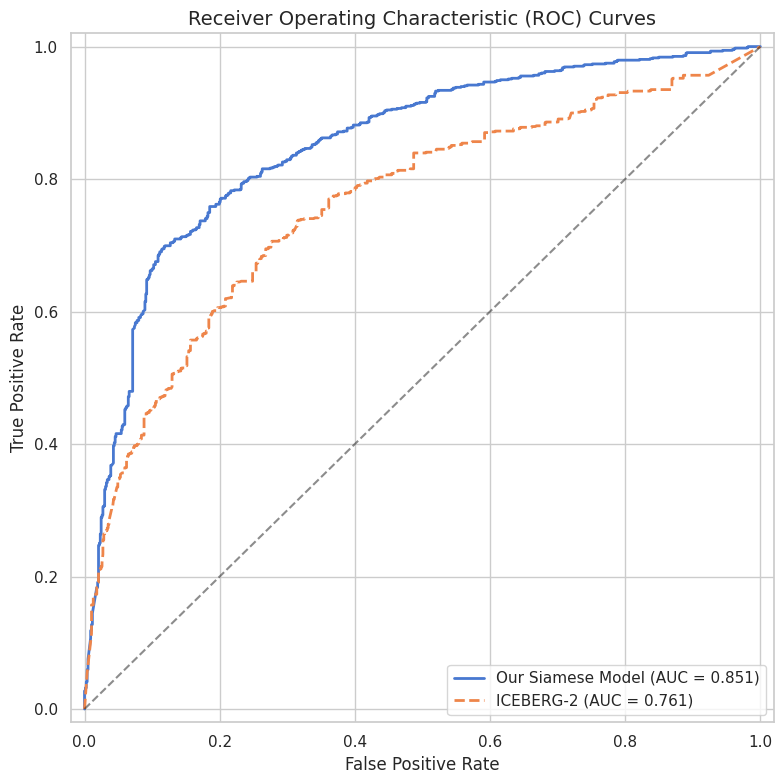

In [6]:
plt.figure(figsize=(8, 8))

# Our Model ROC
fpr_ours, tpr_ours, _ = roc_curve(df_ours['true_label'], df_ours['prob_similarity'])
auc_ours = comparison_df.loc['ROC-AUC', 'Our Siamese Model']
plt.plot(fpr_ours, tpr_ours, label=f'Our Siamese Model (AUC = {auc_ours:.3f})', linewidth=2)

# ICEBERG-2 ROC
fpr_iceb, tpr_iceb, _ = roc_curve(df_iceberg['true_label'], df_iceberg['cosine_similarity'])
auc_iceb = comparison_df.loc['ROC-AUC', 'ICEBERG-2 Baseline']
plt.plot(fpr_iceb, tpr_iceb, label=f'ICEBERG-2 (AUC = {auc_iceb:.3f})', linewidth=2, linestyle='--')

# Random Guess Line
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)

plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.tight_layout()
plt.show()

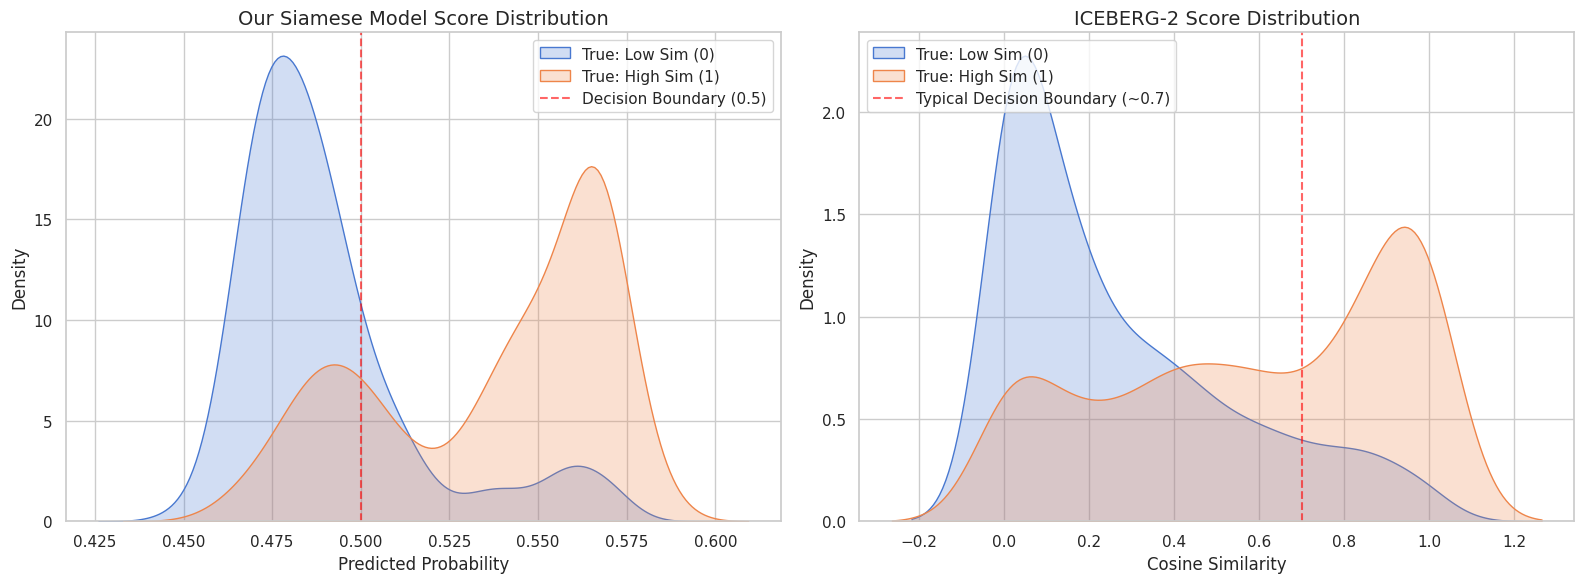

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Our Model Distribution
sns.kdeplot(data=df_ours[df_ours['true_label'] == 0], x='prob_similarity', fill=True, label='True: Low Sim (0)', ax=axes[0])
sns.kdeplot(data=df_ours[df_ours['true_label'] == 1], x='prob_similarity', fill=True, label='True: High Sim (1)', ax=axes[0])
axes[0].set_title('Our Siamese Model Score Distribution')
axes[0].set_xlabel('Predicted Probability')
axes[0].axvline(0.5, color='red', linestyle='--', alpha=0.6, label='Decision Boundary (0.5)')
axes[0].legend()

# ICEBERG-2 Distribution
sns.kdeplot(data=df_iceberg[df_iceberg['true_label'] == 0], x='cosine_similarity', fill=True, label='True: Low Sim (0)', ax=axes[1])
sns.kdeplot(data=df_iceberg[df_iceberg['true_label'] == 1], x='cosine_similarity', fill=True, label='True: High Sim (1)', ax=axes[1])
axes[1].set_title('ICEBERG-2 Score Distribution')
axes[1].set_xlabel('Cosine Similarity')
# Assuming ICEBERG uses something like a 0.70 empirically for the label
axes[1].axvline(0.7, color='red', linestyle='--', alpha=0.6, label='Typical Decision Boundary (~0.7)')
axes[1].legend()

plt.tight_layout()
plt.show()

=== STRICT RELIABILITY TEST (Fixed 5.0% Error Rate) ===
Our Siamese Model:
  -> Required Threshold : 0.5572
  -> Actual Error Rate  : 0.0492
  -> Precision          : 0.9057 (Out of all matches flagged, 90.6% are real)
  -> Recall (Hits)      : 0.4157 (Finds 41.6% of all true matches)

ICEBERG-2 Baseline:
  -> Required Threshold : 0.8524
  -> Actual Error Rate  : 0.0492
  -> Precision          : 0.8892 (Out of all matches flagged, 88.9% are real)
  -> Recall (Hits)      : 0.3474 (Finds 34.7% of all true matches)


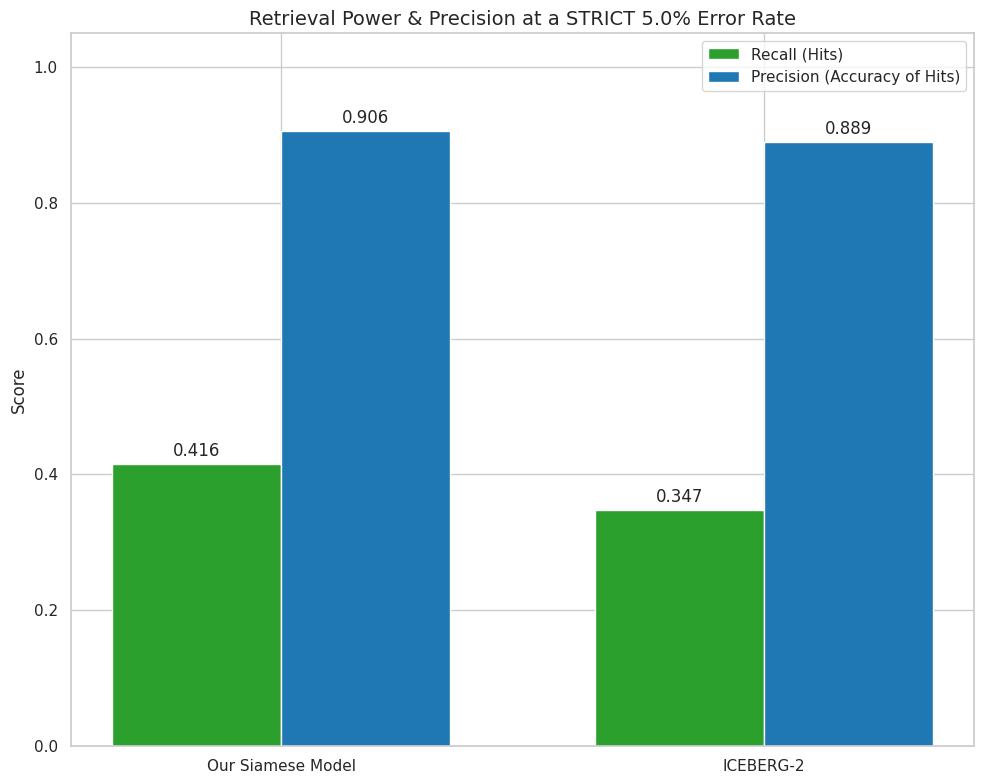

In [8]:
from sklearn.metrics import roc_curve, precision_score

def get_metrics_at_fixed_fpr(y_true, y_prob, target_fpr=0.05):
    """Finds the Recall, Precision, and Threshold at a specific False Positive Rate."""
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    
    # Find the exact index where the FPR is closest to our target without exceeding it
    valid_indices = np.where(fpr <= target_fpr)[0]
    if len(valid_indices) == 0:
        return 0.0, 0.0, 0.0, 0.0
    
    idx = valid_indices[-1]
    strict_threshold = thresholds[idx]
    
    # Manually calculate Precision using this strict threshold
    y_pred_strict = (y_prob >= strict_threshold).astype(int)
    precision = precision_score(y_true, y_pred_strict, zero_division=0)
    
    return fpr[idx], tpr[idx], precision, strict_threshold

TARGET_ERROR_RATE = 0.05 # 5% False Positive Rate Limit

# Calculate for our model
fpr_o, recall_o, prec_o, thresh_o = get_metrics_at_fixed_fpr(
    df_ours['true_label'], df_ours['prob_similarity'], TARGET_ERROR_RATE
)

# Calculate for ICEBERG-2
fpr_i, recall_i, prec_i, thresh_i = get_metrics_at_fixed_fpr(
    df_iceberg['true_label'], df_iceberg['cosine_similarity'], TARGET_ERROR_RATE
)

print(f"=== STRICT RELIABILITY TEST (Fixed {TARGET_ERROR_RATE*100}% Error Rate) ===")
print(f"Our Siamese Model:")
print(f"  -> Required Threshold : {thresh_o:.4f}")
print(f"  -> Actual Error Rate  : {fpr_o:.4f}")
print(f"  -> Precision          : {prec_o:.4f} (Out of all matches flagged, {prec_o*100:.1f}% are real)")
print(f"  -> Recall (Hits)      : {recall_o:.4f} (Finds {recall_o*100:.1f}% of all true matches)")

print(f"\nICEBERG-2 Baseline:")
print(f"  -> Required Threshold : {thresh_i:.4f}")
print(f"  -> Actual Error Rate  : {fpr_i:.4f}")
print(f"  -> Precision          : {prec_i:.4f} (Out of all matches flagged, {prec_i*100:.1f}% are real)")
print(f"  -> Recall (Hits)      : {recall_i:.4f} (Finds {recall_i*100:.1f}% of all true matches)")

# Grouped Bar Plot for visual comparison of both Precision and Recall
plot_labels = ['Our Siamese Model', 'ICEBERG-2']
recall_scores = [recall_o, recall_i]
precision_scores = [prec_o, prec_i]

x = np.arange(len(plot_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 8))
rects1 = ax.bar(x - width/2, recall_scores, width, label='Recall (Hits)', color='#2ca02c')
rects2 = ax.bar(x + width/2, precision_scores, width, label='Precision (Accuracy of Hits)', color='#1f77b4')

ax.set_ylabel('Score')
ax.set_title(f'Retrieval Power & Precision at a STRICT {TARGET_ERROR_RATE*100}% Error Rate')
ax.set_xticks(x)
ax.set_xticklabels(plot_labels)
ax.set_ylim(0, 1.05)
ax.legend()

# Add data labels on top of the bars
ax.bar_label(rects1, fmt='%.3f', padding=3)
ax.bar_label(rects2, fmt='%.3f', padding=3)

plt.tight_layout()
plt.show()

=== PEAK EFFICIENCY (MAX F1) COMPARISON ===
Our Siamese Model:
  -> PR-AUC (Global Reliability): 0.8590
  -> Optimal Threshold          : 0.4953
  -> Peak F1-Score              : 0.7969
  -> Resulting Precision        : 0.7791
  -> Resulting Recall           : 0.8155

ICEBERG-2 Baseline:
  -> PR-AUC (Global Reliability): 0.7958
  -> Optimal Threshold          : 0.1692
  -> Peak F1-Score              : 0.7403
  -> Resulting Precision        : 0.6622
  -> Resulting Recall           : 0.8394


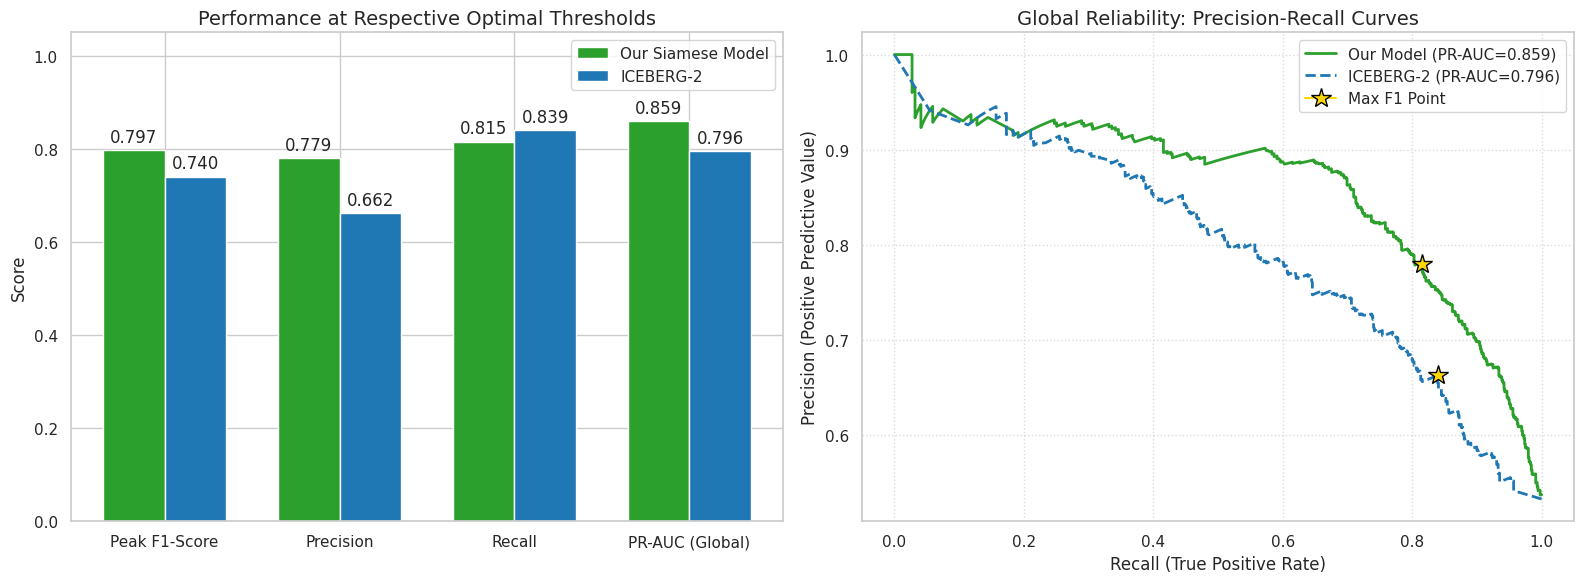

In [9]:
from sklearn.metrics import precision_recall_curve, auc

def get_optimal_f1_metrics(y_true, y_prob):
    """Calculates PR-AUC and finds the exact threshold that maximizes the F1-Score."""
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    
    # Calculate F1 for all thresholds (safe division)
    f1_scores = np.divide(
        2 * (precisions[:-1] * recalls[:-1]), 
        (precisions[:-1] + recalls[:-1]), 
        out=np.zeros_like(precisions[:-1]), 
        where=(precisions[:-1] + recalls[:-1]) != 0
    )
    
    # Find the peak
    best_idx = np.argmax(f1_scores)
    
    # Calculate Area Under the PR Curve (Average Precision)
    pr_auc = auc(recalls, precisions)
    
    return {
        'threshold': thresholds[best_idx],
        'f1': f1_scores[best_idx],
        'precision': precisions[best_idx],
        'recall': recalls[best_idx],
        'pr_auc': pr_auc,
        'all_precisions': precisions,
        'all_recalls': recalls
    }

# Compute optimal metrics for both models
opt_ours = get_optimal_f1_metrics(df_ours['true_label'], df_ours['prob_similarity'])
opt_iceb = get_optimal_f1_metrics(df_iceberg['true_label'], df_iceberg['cosine_similarity'])

print("=== PEAK EFFICIENCY (MAX F1) COMPARISON ===")
print("Our Siamese Model:")
print(f"  -> PR-AUC (Global Reliability): {opt_ours['pr_auc']:.4f}")
print(f"  -> Optimal Threshold          : {opt_ours['threshold']:.4f}")
print(f"  -> Peak F1-Score              : {opt_ours['f1']:.4f}")
print(f"  -> Resulting Precision        : {opt_ours['precision']:.4f}")
print(f"  -> Resulting Recall           : {opt_ours['recall']:.4f}")

print("\nICEBERG-2 Baseline:")
print(f"  -> PR-AUC (Global Reliability): {opt_iceb['pr_auc']:.4f}")
print(f"  -> Optimal Threshold          : {opt_iceb['threshold']:.4f}")
print(f"  -> Peak F1-Score              : {opt_iceb['f1']:.4f}")
print(f"  -> Resulting Precision        : {opt_iceb['precision']:.4f}")
print(f"  -> Resulting Recall           : {opt_iceb['recall']:.4f}")

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Bar Chart of Peak Metrics
labels = ['Peak F1-Score', 'Precision', 'Recall', 'PR-AUC (Global)']
ours_scores = [opt_ours['f1'], opt_ours['precision'], opt_ours['recall'], opt_ours['pr_auc']]
iceb_scores = [opt_iceb['f1'], opt_iceb['precision'], opt_iceb['recall'], opt_iceb['pr_auc']]

x = np.arange(len(labels))
width = 0.35

rects1 = axes[0].bar(x - width/2, ours_scores, width, label='Our Siamese Model', color='#2ca02c')
rects2 = axes[0].bar(x + width/2, iceb_scores, width, label='ICEBERG-2', color='#1f77b4')

axes[0].set_ylabel('Score')
axes[0].set_title('Performance at Respective Optimal Thresholds')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylim(0, 1.05)
axes[0].legend()
axes[0].bar_label(rects1, fmt='%.3f', padding=3)
axes[0].bar_label(rects2, fmt='%.3f', padding=3)

# Plot 2: Precision-Recall Curves overlay
axes[1].plot(opt_ours['all_recalls'], opt_ours['all_precisions'], 
             label=f"Our Model (PR-AUC={opt_ours['pr_auc']:.3f})", color='#2ca02c', linewidth=2)
axes[1].plot(opt_iceb['all_recalls'], opt_iceb['all_precisions'], 
             label=f"ICEBERG-2 (PR-AUC={opt_iceb['pr_auc']:.3f})", color='#1f77b4', linewidth=2, linestyle='--')

# Mark the optimal F1 points on the curves
axes[1].plot(opt_ours['recall'], opt_ours['precision'], marker='*', markersize=15, color='gold', markeredgecolor='black', label='Max F1 Point')
axes[1].plot(opt_iceb['recall'], opt_iceb['precision'], marker='*', markersize=15, color='gold', markeredgecolor='black')

axes[1].set_title('Global Reliability: Precision-Recall Curves')
axes[1].set_xlabel('Recall (True Positive Rate)')
axes[1].set_ylabel('Precision (Positive Predictive Value)')
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

## Analyzing worst hallucinations by our model

In [11]:
# Set the optimal threshold we just discovered
OPTIMAL_THRESHOLD = 0.4953 # (Replace with the actual optimal threshold from Cell 10)

# Define the exact columns to extract for a complete forensic view
# inspect_cols = ['name_main', 'name_sub', 'prob_similarity', 'continuous_pred', 'cosine_similarity']
inspect_cols = ['name_main', 'name_sub', 'prob_similarity', 'cosine_similarity']

# 1. Isolate the False Positives (Model says HIGH probability, Ground Truth says LOW)
false_positives = df_ours[
    (df_ours['prob_similarity'] >= OPTIMAL_THRESHOLD) & 
    (df_ours['true_label'] == 0.0)
].copy()

# Sort by how confident the model was in its mistake
worst_false_positives = false_positives.sort_values(by='prob_similarity', ascending=False)

print(f"[*] Found {len(worst_false_positives)} False Positives at the {OPTIMAL_THRESHOLD} threshold.")
print("\n=== TOP 10 WORST HALLUCINATIONS (False Positives) ===")
display(worst_false_positives[inspect_cols].head(10))


# 2. Isolate the False Negatives (Model says LOW probability, Ground Truth says HIGH)
false_negatives = df_ours[
    (df_ours['prob_similarity'] < OPTIMAL_THRESHOLD) & 
    (df_ours['true_label'] == 1.0)
].copy()

# Sort by how confidently wrong the model was (lowest probability first)
worst_false_negatives = false_negatives.sort_values(by='prob_similarity', ascending=True)

print("\n=== TOP 10 MISSED DISCOVERIES (False Negatives) ===")
display(worst_false_negatives[inspect_cols].head(10))

[*] Found 203 False Positives at the 0.4953 threshold.

=== TOP 10 WORST HALLUCINATIONS (False Positives) ===


,name_main,name_sub,prob_similarity,cosine_similarity
1519,MassSpecGymID0234862,MassSpecGymID0235348,0.575704,0.522514
904,MassSpecGymID0217791,MassSpecGymID0217865,0.574322,0.636646
1368,MassSpecGymID0003938,MassSpecGymID0020238,0.572243,0.638620
610,MassSpecGymID0078914,MassSpecGymID0079020,0.570459,0.643693
1600,MassSpecGymID0109538,MassSpecGymID0110023,0.570126,0.188363
1470,MassSpecGymID0109540,MassSpecGymID0110023,0.570126,0.440087
965,MassSpecGymID0109536,MassSpecGymID0110021,0.570126,0.434970
1404,MassSpecGymID0216206,MassSpecGymID0218908,0.569720,0.612961
1646,MassSpecGymID0217668,MassSpecGymID0217677,0.569547,0.522950
375,MassSpecGymID0114768,MassSpecGymID0122560,0.569342,0.528060



=== TOP 10 MISSED DISCOVERIES (False Negatives) ===


,name_main,name_sub,prob_similarity,cosine_similarity
1287,MassSpecGymID0204304,MassSpecGymID0207751,0.458852,0.913071
360,MassSpecGymID0215504,MassSpecGymID0233891,0.459215,0.874910
798,MassSpecGymID0203812,MassSpecGymID0213836,0.462360,0.911048
887,MassSpecGymID0203811,MassSpecGymID0213835,0.462542,0.934032
664,MassSpecGymID0213470,MassSpecGymID0223774,0.462965,0.832525
456,MassSpecGymID0228293,MassSpecGymID0233425,0.464116,0.853173
1052,MassSpecGymID0203970,MassSpecGymID0236285,0.465430,0.874536
637,MassSpecGymID0206351,MassSpecGymID0221529,0.465532,0.964127
1207,MassSpecGymID0204304,MassSpecGymID0207597,0.467078,0.884695
1173,MassSpecGymID0223776,MassSpecGymID0237811,0.467183,0.852920


[*] Loading relational metadata...
[*] Building SMILES and Peaks lookup dictionaries...

 🔬 UNIFIED FORENSICS: TOPOLOGY + SPECTRA HALLUCINATIONS


/tmp/ipykernel_1607218/893511366.py:137: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax_spec.set_yticklabels([f"{abs(t):.1f}" for t in ticks])


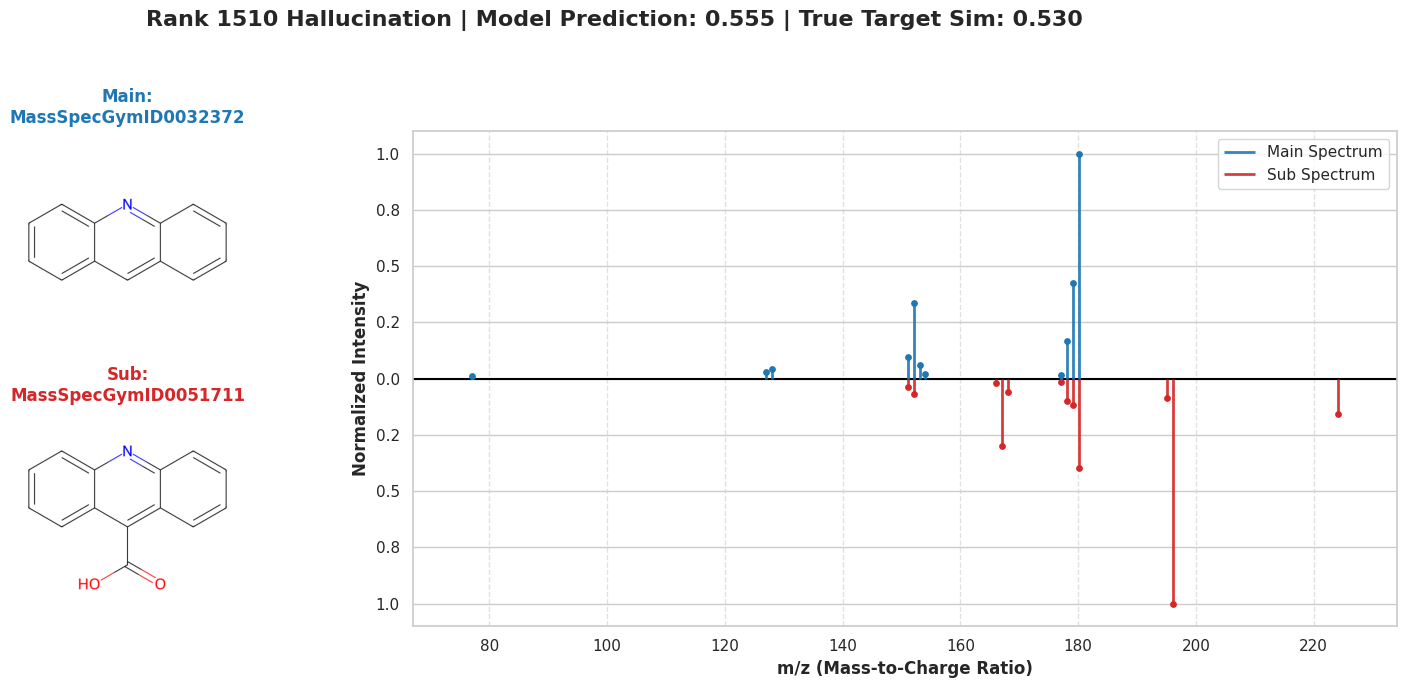

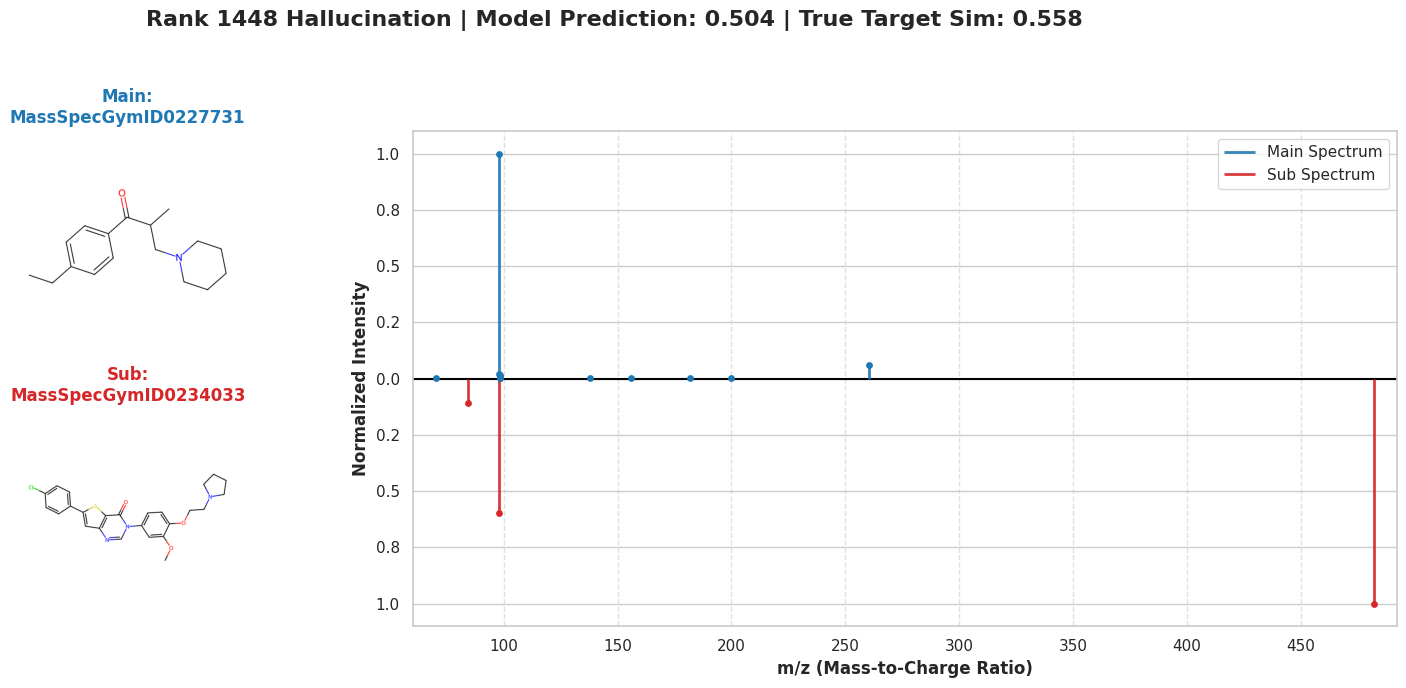

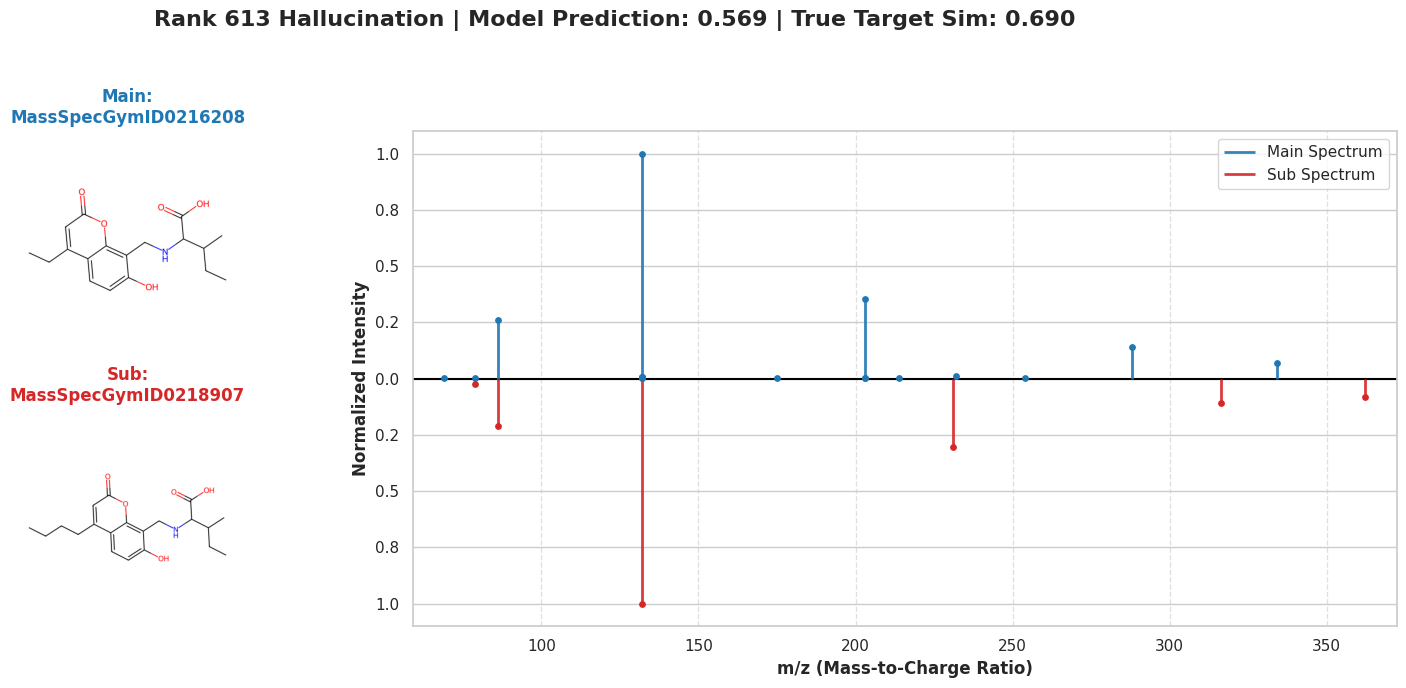

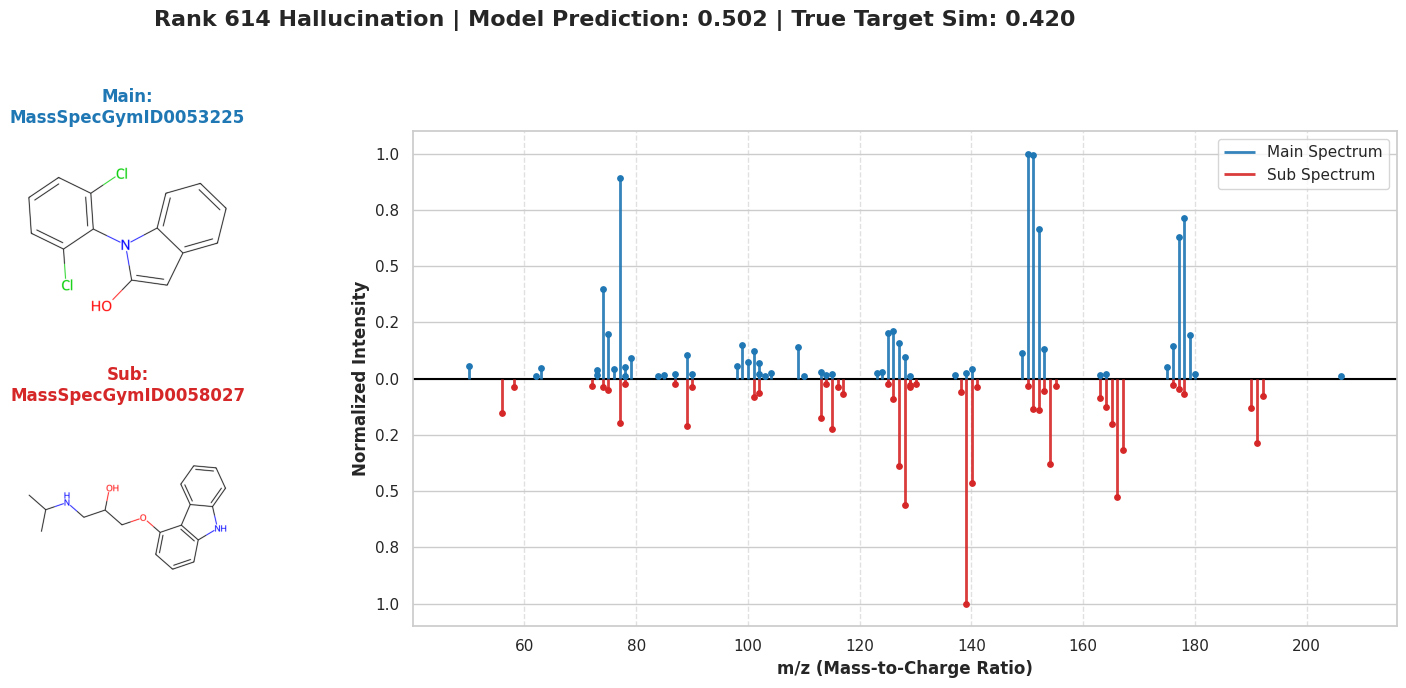

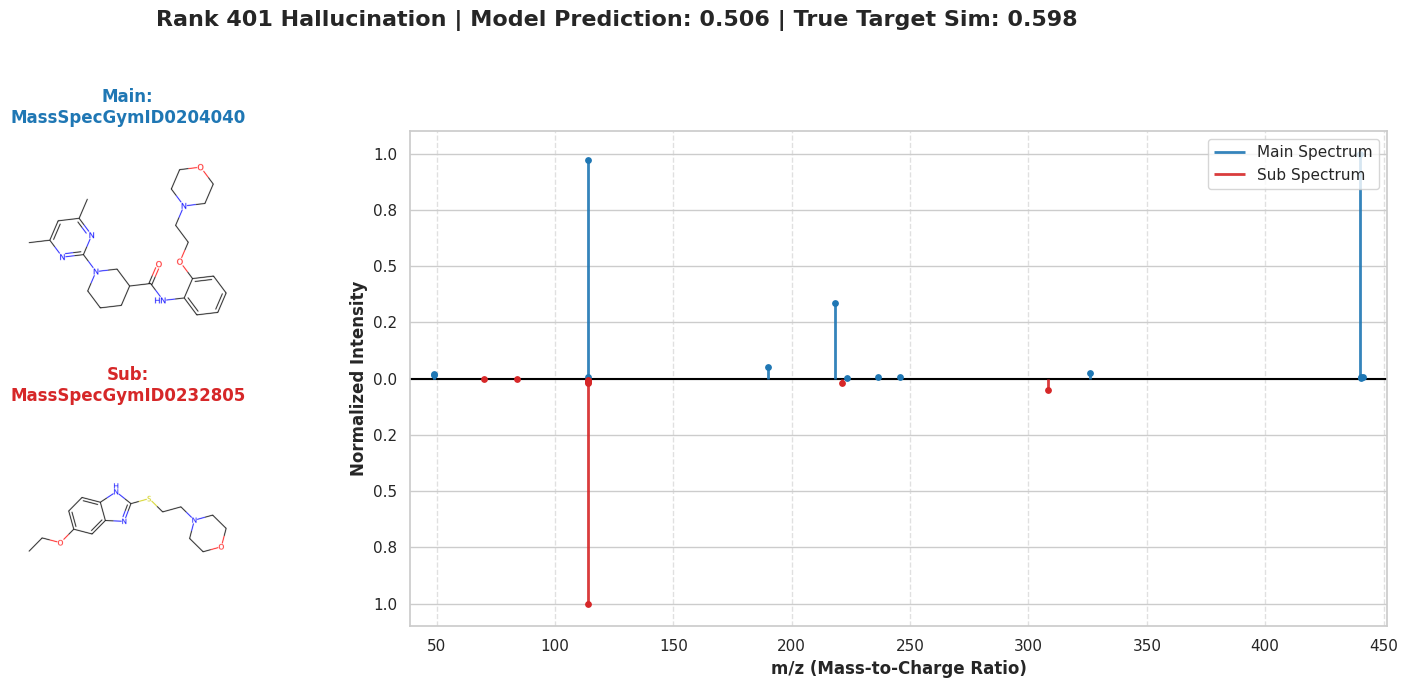

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
from rdkit import Chem
from rdkit.Chem import Draw

# =================================================================
# 1. PATH CONFIGURATION (Ensure these are your actual .pkl paths)
# =================================================================
SPEC_DF_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"
MOL_DF_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df.pkl"

print(f"[*] Loading relational metadata...")
try:
    spec_df = pd.read_pickle(SPEC_DF_PATH)
    mol_df = pd.read_pickle(MOL_DF_PATH)
except Exception as e:
    print(f"[-] Error loading pickle files: {e}")

# =================================================================
# 2. CREATE LOOKUP DICTIONARIES
# =================================================================
print("[*] Building SMILES and Peaks lookup dictionaries...")
# Map mol_id -> smiles
mol_to_smiles = dict(zip(mol_df['mol_id'], mol_df['smiles']))

# Map spec_id -> smiles AND spec_id -> peaks
smiles_dict = {}
peaks_dict = {}

for _, row in spec_df.iterrows():
    s_id = row['spec_id']
    smiles_dict[s_id] = mol_to_smiles.get(row['mol_id'])
    peaks_dict[s_id] = row['peaks']

# =================================================================
# 3. PEAK PARSING FUNCTION
# =================================================================
def parse_and_normalize_peaks(peaks_raw):
    """Safely extracts m/z and normalizes intensities to 1.0 max."""
    if isinstance(peaks_raw, str):
        try:
            peaks = ast.literal_eval(peaks_raw)
        except Exception:
            return np.array([]), np.array([])
    else:
        peaks = peaks_raw
        
    if not peaks or len(peaks) == 0:
        return np.array([]), np.array([])
        
    mz = np.array([p[0] for p in peaks])
    intensity = np.array([p[1] for p in peaks])
    
    max_int = np.max(intensity)
    if max_int > 0:
        intensity = intensity / max_int
        
    return mz, intensity

# =================================================================
# 4. EXTRACT TOP 5 FALSE POSITIVES
# =================================================================
top_5_fps = worst_false_positives.sample(n=5, random_state=None).copy()

print("\n" + "="*90)
print(" 🔬 UNIFIED FORENSICS: TOPOLOGY + SPECTRA HALLUCINATIONS")
print("="*90)

# =================================================================
# 5. RENDER UNIFIED PLOTS
# =================================================================
for idx, row in top_5_fps.iterrows():
    name_m, name_s = row['name_main'], row['name_sub']
    prob_sim = row['prob_similarity']
    
    # Get True Similarity Column
    true_sim_col = [c for c in row.index if 'entropy' in c or 'cosine' in c or c == 'continuous_pred']
    true_val = row[true_sim_col[0]] if true_sim_col else "N/A"
    
    # Fetch Data
    smiles_m, smiles_s = smiles_dict.get(name_m), smiles_dict.get(name_s)
    peaks_m_raw, peaks_s_raw = peaks_dict.get(name_m, []), peaks_dict.get(name_s, [])
    
    # Parse Molecules
    mol_m = Chem.MolFromSmiles(str(smiles_m)) if pd.notna(smiles_m) else None
    mol_s = Chem.MolFromSmiles(str(smiles_s)) if pd.notna(smiles_s) else None
    
    # Parse Peaks
    mz_m, int_m = parse_and_normalize_peaks(peaks_m_raw)
    mz_s, int_s = parse_and_normalize_peaks(peaks_s_raw)
    
    if mol_m is None or mol_s is None or len(mz_m) == 0 or len(mz_s) == 0:
        print(f"[!] Rank {idx}: Missing data for {name_m} or {name_s}. Skipping.")
        continue

    # =================================================================
    # [THE FIX] Adjusted GridSpec for Balanced Proportions
    # width_ratios=[1.2, 2] gives the molecules ~37% of the screen width
    # =================================================================
    fig = plt.figure(figsize=(16, 7)) 
    gs = fig.add_gridspec(2, 2, width_ratios=[1.2, 2])
    
    # Subplot: Main Molecule Image
    ax_mol_m = fig.add_subplot(gs[0, 0])
    # Increased RDKit rendering size to 500x500 for better clarity when scaled
    img_m = Draw.MolToImage(mol_m, size=(500, 500)) 
    ax_mol_m.imshow(img_m)
    ax_mol_m.axis('off')
    ax_mol_m.set_title(f"Main:\n{name_m}", fontsize=12, color='#1f77b4', fontweight='bold')
    
    # Subplot: Sub Molecule Image
    ax_mol_s = fig.add_subplot(gs[1, 0])
    img_s = Draw.MolToImage(mol_s, size=(500, 500))
    ax_mol_s.imshow(img_s)
    ax_mol_s.axis('off')
    ax_mol_s.set_title(f"Sub:\n{name_s}", fontsize=12, color='#d62728', fontweight='bold')
    
    # Subplot: Mirror Plot (Spans 2 rows, takes up column 1)
    ax_spec = fig.add_subplot(gs[:, 1])
    
    # Plot Spectra
    ax_spec.vlines(mz_m, 0, int_m, color='#1f77b4', linewidth=2, alpha=0.9, label='Main Spectrum')
    ax_spec.scatter(mz_m, int_m, color='#1f77b4', s=15, zorder=3)
    
    ax_spec.vlines(mz_s, 0, -int_s, color='#d62728', linewidth=2, alpha=0.9, label='Sub Spectrum')
    ax_spec.scatter(mz_s, -int_s, color='#d62728', s=15, zorder=3)
    
    # Centerline & Axis Formatting
    ax_spec.axhline(0, color='black', linewidth=1.5, zorder=1)
    ax_spec.set_xlabel("m/z (Mass-to-Charge Ratio)", fontweight='bold', fontsize=12)
    ax_spec.set_ylabel("Normalized Intensity", fontweight='bold', fontsize=12)
    
    # Format Y-axis to show positive numbers on bottom
    ticks = ax_spec.get_yticks()
    ax_spec.set_yticklabels([f"{abs(t):.1f}" for t in ticks])
    
    ax_spec.grid(True, axis='x', linestyle='--', alpha=0.6)
    ax_spec.legend(loc='upper right')
    
    # X/Y Limits
    min_mz = min(np.min(mz_m), np.min(mz_s)) - 10
    max_mz = max(np.max(mz_m), np.max(mz_s)) + 10
    ax_spec.set_xlim(max(0, min_mz), max_mz)
    ax_spec.set_ylim(-1.1, 1.1)
    
    # Overall Title
    fig.suptitle(f"Rank {idx} Hallucination | Model Prediction: {prob_sim:.3f} | True Target Sim: {true_val:.3f}", 
                 fontsize=16, fontweight='bold', y=0.98)
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()